In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.set_printoptions(precision=2, suppress=True)

In [3]:
# Visualize the graph
def visualize_graph(gg: nx.DiGraph, title: str):
    plt.figure(figsize=(6, 4))
    # pos = nx.spring_layout(gg, seed=42)
    pos = nx.circular_layout(gg)
    nx.draw(gg, pos, with_labels=True, node_color='lightblue', 
    node_size=500, font_size=12, font_weight='bold', 
    arrows=True, arrowsize=20, edge_color='gray')
    plt.title(title)
    plt.show()

import enum
class Dangling_Mode(enum.Enum):
    """Enum for handling dangling nodes in PageRank calculations."""

    PAGERANK_0 = "nothing"
    PAGERANK_1 = "add_self_loops"
    PAGERANK_2 = "add_links_to_all"


def generate_transition_matrix(gg):
    # Get the transition matrix for the Markov Chain
    transition_matrix = nx.to_numpy_array(gg, nodelist=sorted(gg.nodes()))
    # Normalize rows to get probabilities (each row sums to 1)
    row_sums = transition_matrix.sum(axis=1)
    np.divide(transition_matrix, row_sums[:, None], out=transition_matrix, where=row_sums[:, None] != 0)
    return transition_matrix


def pagerank(gg: nx.DiGraph,
             mode: Dangling_Mode = Dangling_Mode.PAGERANK_0,
             ss: float = 1, 
             init_scores: np.ndarray = None, 
             iter: int = 10, tol: float = 1e-3,
             verbose: bool = False):

    gg = gg.copy()  # Work on a copy of the graph to avoid modifying the original
    
    if mode != Dangling_Mode.PAGERANK_0:
        # Deal with dangling nodes
        dangling_nodes = [n for n in gg.nodes() if gg.out_degree(n) == 0]
        if mode == Dangling_Mode.PAGERANK_1:
                for n in dangling_nodes:
                    gg.add_edge(n, n)
        elif mode == Dangling_Mode.PAGERANK_2:
            for n in dangling_nodes:
                for m in gg.nodes():
                    gg.add_edge(n, m)

    nn = gg.number_of_nodes()

    # Initialize the PageRank vector
    if init_scores is None:
        init_scores = np.ones((1, nn)) / nn
    
    pr = init_scores

    tm = generate_transition_matrix(gg)
    tm = (1 - ss) * np.ones_like(tm) / nn + ss * tm

    power_matrix = np.eye(nn)  # Start with the identity matrix

    if verbose:
        print("Iteration 0::")
        print("Sum of PageRank scores:", np.sum(pr))
        print("PageRank scores:", pr, end='\n\n')

    for i in range(iter):
        # update the power matrix
        # NOTE 
        # Maintaining the power matrix is unnecessary and inefficient 
        # if we are only interested in the PageRank scores.
        # TODO Exercise: Explain why.
        power_matrix = np.dot(tm, power_matrix)
        
        # Compute the new PageRank values
        new_pr = np.dot(init_scores, power_matrix)
        diff = np.linalg.norm(new_pr - pr)
        pr = new_pr

        if verbose:
            print(f"Iteration {i+1}::")
            print("Sum of PageRank scores: {:<.2f}".format(np.sum(pr)))
            print("PageRank scores:", pr)
            print("Power matrix: M^{} =".format(i+1))
            print(*power_matrix, sep = "\n", end='\n\n')

        # Check for convergence
        if iter is None and diff < tol:
            break
        
    return pr


If dangling nodes exist then, in general, PageRank-0 returns a vector that is not a probability distribution (i.e., the values of the vector do not sum up to 1).

To see that, consider this simple graph with one dangling node.

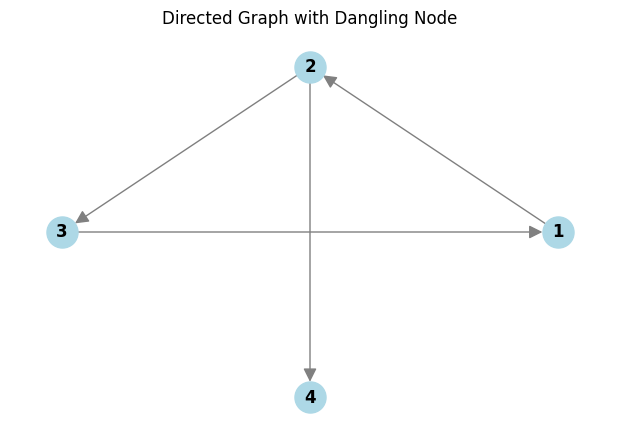

In [4]:
gg = nx.DiGraph()
gg.add_edges_from([(1, 2), (2, 3), (3, 1), (2, 4)])
visualize_graph(gg, "Directed Graph with Dangling Node")

Let's employ PageRank-0 on this graph.

In [5]:
pagerank(gg, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.25 0.25 0.25 0.25]]

Iteration 1::
Sum of PageRank scores: 0.75
PageRank scores: [[0.25 0.25 0.12 0.12]]
Power matrix: M^1 =
[0. 1. 0. 0.]
[0.  0.  0.5 0.5]
[1. 0. 0. 0.]
[0. 0. 0. 0.]

Iteration 2::
Sum of PageRank scores: 0.62
PageRank scores: [[0.12 0.25 0.12 0.12]]
Power matrix: M^2 =
[0.  0.  0.5 0.5]
[0.5 0.  0.  0. ]
[0. 1. 0. 0.]
[0. 0. 0. 0.]

Iteration 3::
Sum of PageRank scores: 0.50
PageRank scores: [[0.12 0.12 0.12 0.12]]
Power matrix: M^3 =
[0.5 0.  0.  0. ]
[0.  0.5 0.  0. ]
[0.  0.  0.5 0.5]
[0. 0. 0. 0.]

Iteration 4::
Sum of PageRank scores: 0.38
PageRank scores: [[0.12 0.12 0.06 0.06]]
Power matrix: M^4 =
[0.  0.5 0.  0. ]
[0.   0.   0.25 0.25]
[0.5 0.  0.  0. ]
[0. 0. 0. 0.]

Iteration 5::
Sum of PageRank scores: 0.31
PageRank scores: [[0.06 0.12 0.06 0.06]]
Power matrix: M^5 =
[0.   0.   0.25 0.25]
[0.25 0.   0.   0.  ]
[0.  0.5 0.  0. ]
[0. 0. 0. 0.]

Iteration 6::
Sum of PageRank scores: 0.25
PageRank

array([[0.03, 0.03, 0.02, 0.02]])

As we can see, the total PageRank score gradually decreases with every iteration.

This issue is resolved by both variants PageRank-1/2, as they ensure the transition matrix is row-stochastic.

Let's try first PageRank-1.

In [6]:
pagerank(gg, mode=Dangling_Mode.PAGERANK_1, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.25 0.25 0.25 0.25]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.25 0.12 0.38]]
Power matrix: M^1 =
[0. 1. 0. 0.]
[0.  0.  0.5 0.5]
[1. 0. 0. 0.]
[0. 0. 0. 1.]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.25 0.12 0.5 ]]
Power matrix: M^2 =
[0.  0.  0.5 0.5]
[0.5 0.  0.  0.5]
[0. 1. 0. 0.]
[0. 0. 0. 1.]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.12 0.12 0.62]]
Power matrix: M^3 =
[0.5 0.  0.  0.5]
[0.  0.5 0.  0.5]
[0.  0.  0.5 0.5]
[0. 0. 0. 1.]

Iteration 4::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.12 0.06 0.69]]
Power matrix: M^4 =
[0.  0.5 0.  0.5]
[0.   0.   0.25 0.75]
[0.5 0.  0.  0.5]
[0. 0. 0. 1.]

Iteration 5::
Sum of PageRank scores: 1.00
PageRank scores: [[0.06 0.12 0.06 0.75]]
Power matrix: M^5 =
[0.   0.   0.25 0.75]
[0.25 0.   0.   0.75]
[0.  0.5 0.  0.5]
[0. 0. 0. 1.]

Iteration 6::
Sum of PageRank scores: 1.00
PageRank

array([[0.03, 0.03, 0.02, 0.92]])

We notice that the computed scores vector is now a probability distribution (non-negative elements that sum up to 1).

Notice also, however, that one of the nodes (4) also concentrates the full probability mass, leaving other nodes with score 0. This is because a random walk over the network eventually is trapped at that node. 

In Markov Chain terminology, node (4) constitutes the single recurrent class of the MC represented by the transition matrix.

Let's see what happens with PageRank-2.

In [7]:
pagerank(gg, mode=Dangling_Mode.PAGERANK_2, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.25 0.25 0.25 0.25]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.31 0.31 0.19 0.19]]
Power matrix: M^1 =
[0. 1. 0. 0.]
[0.  0.  0.5 0.5]
[1. 0. 0. 0.]
[0.25 0.25 0.25 0.25]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.23 0.36 0.2  0.2 ]]
Power matrix: M^2 =
[0.  0.  0.5 0.5]
[0.62 0.12 0.12 0.12]
[0. 1. 0. 0.]
[0.31 0.31 0.19 0.19]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.29 0.23 0.23]]
Power matrix: M^3 =
[0.62 0.12 0.12 0.12]
[0.16 0.66 0.09 0.09]
[0.  0.  0.5 0.5]
[0.23 0.36 0.2  0.2 ]

Iteration 4::
Sum of PageRank scores: 1.00
PageRank scores: [[0.29 0.31 0.2  0.2 ]]
Power matrix: M^4 =
[0.16 0.66 0.09 0.09]
[0.12 0.18 0.35 0.35]
[0.62 0.12 0.12 0.12]
[0.25 0.29 0.23 0.23]

Iteration 5::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.34 0.21 0.21]]
Power matrix: M^5 =
[0.12 0.18 0.35 0.35]
[0.44 0.21 0.18 0.18]
[0.16 0.66 0.09 0.09]
[0.29 0.31

array([[0.27, 0.31, 0.21, 0.21]])

Similarly to the first variant, PageRank-2 returns a probability distribution, but this time it happens that the scores are distributed over all nodes. 

Attention, though! This is not a general property of PageRank-2 (i.e., to ensure that all nodes receive a positive score as $n\rightarrow \infty$, it does not suffice to add edges from dangling nodes to all nodes).

**Exercise** Provide two graphs, one with and one without dangling nodes, for which, at the limit of infinite iterations, PageRank-2 assigns score 0 to some nodes regardless of the initial assignment.

# Convergence 

In what follows, we will always be dealing with a row-stochastic transition matrix $M$.

We ask:
- Does $\pi_0 M^t$ converge as $t\rightarrow\infty$?
- If so, what is the limit?
- Does the convergergence depend on the initial score distribution $\pi_0$?

## The effect of Periodicity

First, if the Markov Chain has one or more periodic recurrent classes, then 
* $M^t$ does not converge, 
* and so neither does $\pi_0 M^t$ for general $\pi_0$,
* but $\pi_0 M^t$ happens to converge for some special values of $\pi_0$. 

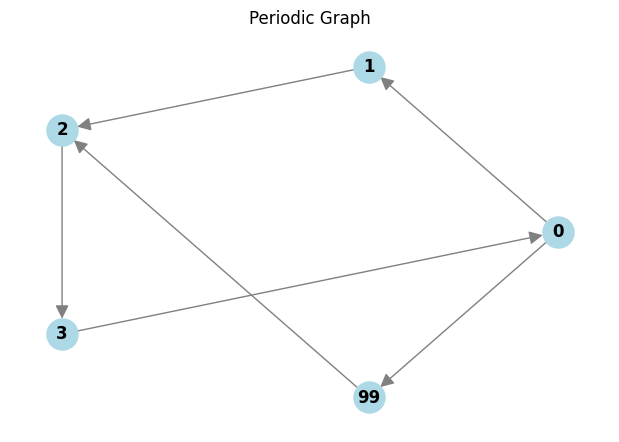

In [8]:
periodic_graph = nx.DiGraph()
nn = 4
# Add edges to the periodic graph
for ii in range(nn):
    periodic_graph.add_edge(ii, (ii + 1) % nn)

periodic_graph.add_edge(0,99)
periodic_graph.add_edge(99,2)

visualize_graph(periodic_graph, "Periodic Graph")


In [9]:
init_scores = np.zeros((1, periodic_graph.number_of_nodes()))
init_scores[0, 0] = 1  # Set the initial score to 1 for the first node
pagerank(periodic_graph, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[1. 0. 0. 0. 0.]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.5 0.  0.  0.5]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0. 0. 1. 0. 0.]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0. 0. 1. 0. 0.]]
Power matrix: M^2 =
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 0. 1. 0.]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0. 0. 0. 1. 0.]]
Power matrix: M^3 =
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[1. 0. 0. 0. 0.]

Iteration 4::
Sum of PageRank scores: 1.00
PageRank scores: [[1. 0. 0. 0. 0.]]
Power matrix: M^4 =
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[0.  0.5 0.  0.  0.5]

Iteration 5::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.5 0.  0.  0.5]]
Power matrix: M^5 =
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0

array([[0., 0., 1., 0., 0.]])

Notice that the power matrix does not converge, and neither does the resulting distribution (scores).

We get similar results for other initial distributions.

In [10]:
init_scores = np.ones((1, periodic_graph.number_of_nodes())) / periodic_graph.number_of_nodes()
pagerank(periodic_graph, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, iter=10, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.2 0.2 0.2 0.2 0.2]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.2 0.1 0.4 0.2 0.1]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0. 0. 1. 0. 0.]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.2 0.1 0.2 0.4 0.1]]
Power matrix: M^2 =
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 0. 1. 0.]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.4 0.1 0.2 0.2 0.1]]
Power matrix: M^3 =
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[1. 0. 0. 0. 0.]

Iteration 4::
Sum of PageRank scores: 1.00
PageRank scores: [[0.2 0.2 0.2 0.2 0.2]]
Power matrix: M^4 =
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[0.  0.5 0.  0.  0.5]

Iteration 5::
Sum of PageRank scores: 1.00
PageRank scores: [[0.2 0.1 0.4 0.2 0.1]]
Power matrix: M^5 =
[0.  0.5 0.  0.  0.5]
[0. 0

array([[0.2, 0.1, 0.2, 0.4, 0.1]])

Note that there are some special values of $\pi_0$ that lead to convergence -- see the example below.

In [11]:
init_scores = np.empty((1, periodic_graph.number_of_nodes())) 
init_scores[(0, 0)] = 0.25  
init_scores[(0, 1)] = 0.125  
init_scores[(0, 2)] = 0.25  
init_scores[(0, 3)] = 0.25  
init_scores[(0, 4)] = 0.125 
pagerank(periodic_graph, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, iter=6, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0. 0. 1. 0. 0.]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]
Power matrix: M^2 =
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 0. 1. 0.]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]
Power matrix: M^3 =
[0. 0. 0. 1. 0.]
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[1. 0. 0. 0. 0.]

Iteration 4::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]
Power matrix: M^4 =
[1. 0. 0. 0. 0.]
[0.  0.5 0.  0.  0.5]
[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[0.  0.5 0.  0.  0.5]

Iteration 5::
Sum of PageRank scores: 1.00
PageRank scores: [[0.25 0.12 0.25 0.25 0.12]]
Power matrix: M^5

array([[0.25, 0.12, 0.25, 0.25, 0.12]])

The situation is similar for more general cases of periodic Markov chains -- see the example below.

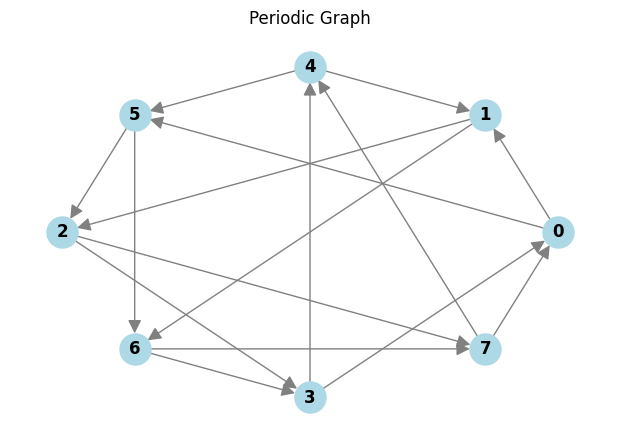

In [12]:
periodic_classes_graph = nx.DiGraph()
# Add edges to the periodic graph
nn = 4
for i in range(nn):
    periodic_classes_graph.add_edge(i, (i + 1) % nn)
    periodic_classes_graph.add_edge(nn + i, (i + 1) % nn)
    periodic_classes_graph.add_edge(i, nn + (i + 1) % nn)
    periodic_classes_graph.add_edge(nn + i, nn + (i + 1) % nn)
nn = periodic_classes_graph.number_of_nodes()
visualize_graph(periodic_classes_graph, "Periodic Graph")

In [13]:
nn = periodic_classes_graph.number_of_nodes()
init_scores = np.zeros((1, nn))
init_scores[0, 0] = 1  # Set the initial score to 1 for the first node
pagerank(periodic_classes_graph, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[1. 0. 0. 0. 0. 0. 0. 0.]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.5 0.  0.  0.  0.5 0.  0. ]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.  0.5 0.  0.  0.  0.5 0. ]]
Power matrix: M^2 =
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.  0.  0.5 0.  0.  0.  0.5]]
Power matrix: M^3 =
[0.  0.  0.  0.5 0

array([[0. , 0. , 0.5, 0. , 0. , 0. , 0.5, 0. ]])

In [14]:
eps = 1/(4*nn)
init_scores = np.zeros((1, nn))
init_scores[0, 0] = 1/nn + eps 
init_scores[0, 1] = 1/nn + eps 
init_scores[0, 2] = 1/nn + eps  
init_scores[0, 3] = 1/nn + eps  
init_scores[0, 4] = 1/nn - eps 
init_scores[0, 5] = 1/nn - eps 
init_scores[0, 6] = 1/nn - eps  
init_scores[0, 7] = 1/nn - eps  
pagerank(periodic_classes_graph, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, iter = 6, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0.16 0.16 0.16 0.16 0.09 0.09 0.09 0.09]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]]
Power matrix: M^2 =
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.  0.  0.  0.5 0. ]
[0.  0.  0.  0.5 0.  0.  0.  0.5]
[0.5 0.  0.  0.  0.5 0.  0.  0. ]
[0.  0.5 0.  0.  0.  0.5 0.  0. ]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]

array([[0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]])

**Exercise** The above examples do not contain dangling nodes -- so PageRank-1 & 2 had identical execution. Can you find examples of graphs with dangling nodes that show a similar effect as above, i.e., that PageRank-1 & 2 do not converge for all starting distributions $\pi_0$?

## The effect of Multiple Recurrent Classes 

If the MC has no periodic recurrent classes, then ... 
- $M^t$ converges for $t\rightarrow \infty$,
- but if there are multiple recurrent classes, then the limit of $M^n$ contains non-identical rows and $\pi_0M^n$ still depends on $\pi_0$.

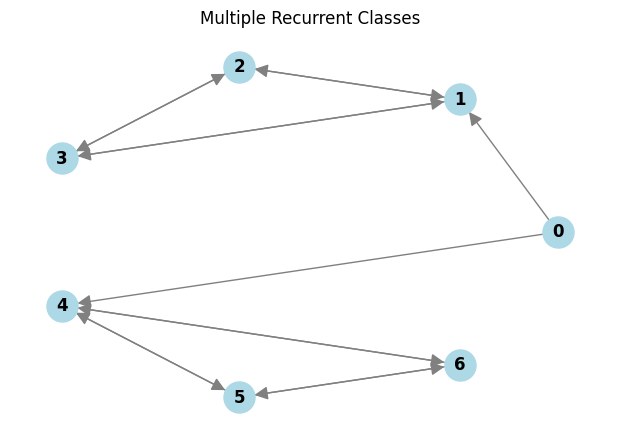

In [15]:
multi_rec = nx.DiGraph()
multi_rec.add_edges_from([(0, 1), (1, 2), (2,1), (2, 3), (3,2), (1,3), (3,1), (0,4), (4, 5), (5,4), (4,6), (5, 6), (6,4), (6,5)])
visualize_graph(multi_rec, "Multiple Recurrent Classes")

In [16]:
pagerank(multi_rec, mode=Dangling_Mode.PAGERANK_2, verbose=True)

Iteration 0::
Sum of PageRank scores: 0.9999999999999998
PageRank scores: [[0.14 0.14 0.14 0.14 0.14 0.14 0.14]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.   0.21 0.14 0.14 0.21 0.14 0.14]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.5 0.  0.  0. ]
[0.  0.5 0.  0.5 0.  0.  0. ]
[0.  0.5 0.5 0.  0.  0.  0. ]
[0.  0.  0.  0.  0.  0.5 0.5]
[0.  0.  0.  0.  0.5 0.  0.5]
[0.  0.  0.  0.  0.5 0.5 0. ]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.   0.14 0.18 0.18 0.14 0.18 0.18]]
Power matrix: M^2 =
[0.   0.   0.25 0.25 0.   0.25 0.25]
[0.   0.5  0.25 0.25 0.   0.   0.  ]
[0.   0.25 0.5  0.25 0.   0.   0.  ]
[0.   0.25 0.25 0.5  0.   0.   0.  ]
[0.   0.   0.   0.   0.5  0.25 0.25]
[0.   0.   0.   0.   0.25 0.5  0.25]
[0.   0.   0.   0.   0.25 0.25 0.5 ]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.   0.18 0.16 0.16 0.18 0.16 0.16]]
Power matrix: M^3 =
[0.   0.25 0.12 0.12 0.25 0.12 0.12]
[0.   0.25 0.38 0.38 

array([[0.  , 0.17, 0.17, 0.17, 0.17, 0.17, 0.17]])

We observe that the iteration converges for uniform initial assignment.

But what if we have a different $\pi_0$?

In [17]:
nn = multi_rec.number_of_nodes()
init_scores = np.zeros((1, nn))
init_scores[0, 2] = 1 
pagerank(multi_rec, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, verbose=True)

Iteration 0::
Sum of PageRank scores: 1.0
PageRank scores: [[0. 0. 1. 0. 0. 0. 0.]]

Iteration 1::
Sum of PageRank scores: 1.00
PageRank scores: [[0.  0.5 0.  0.5 0.  0.  0. ]]
Power matrix: M^1 =
[0.  0.5 0.  0.  0.5 0.  0. ]
[0.  0.  0.5 0.5 0.  0.  0. ]
[0.  0.5 0.  0.5 0.  0.  0. ]
[0.  0.5 0.5 0.  0.  0.  0. ]
[0.  0.  0.  0.  0.  0.5 0.5]
[0.  0.  0.  0.  0.5 0.  0.5]
[0.  0.  0.  0.  0.5 0.5 0. ]

Iteration 2::
Sum of PageRank scores: 1.00
PageRank scores: [[0.   0.25 0.5  0.25 0.   0.   0.  ]]
Power matrix: M^2 =
[0.   0.   0.25 0.25 0.   0.25 0.25]
[0.   0.5  0.25 0.25 0.   0.   0.  ]
[0.   0.25 0.5  0.25 0.   0.   0.  ]
[0.   0.25 0.25 0.5  0.   0.   0.  ]
[0.   0.   0.   0.   0.5  0.25 0.25]
[0.   0.   0.   0.   0.25 0.5  0.25]
[0.   0.   0.   0.   0.25 0.25 0.5 ]

Iteration 3::
Sum of PageRank scores: 1.00
PageRank scores: [[0.   0.38 0.25 0.38 0.   0.   0.  ]]
Power matrix: M^3 =
[0.   0.25 0.12 0.12 0.25 0.12 0.12]
[0.   0.25 0.38 0.38 0.   0.   0.  ]
[0.   0.38 0.25 0.38

array([[0.  , 0.33, 0.33, 0.33, 0.  , 0.  , 0.  ]])

The iteration converges again, but to a different value than before.

Neither PageRank-1 or 2 can generally break this dependency on $\pi_0$.

**Exercise** Provide examples of graphs with dangling nodes for which Pagerank-1 and 2 converge, but the limit depends on the starting distribution $\pi_0$.

## The effect of Scaling

Finally, if the MC is aperiodic and has only a single recurrent class (no transient nodes), then
- $M^t$ converges to identical rows and so
- $\pi_0 M^t$ converges to the same limit for all distributions $\pi_0$.
- Moreover, all nodes have a positive score.

This condition is guaranteed by the "scaling". Why?

In [39]:
revisited_gg = multi_rec # periodic_classes_graph # multi_rec
init_scores = np.random.rand(1, revisited_gg.number_of_nodes())
init_scores /= init_scores.sum()
print("Initial Scores:", init_scores)
pr_score = pagerank(revisited_gg, ss = 0.85, mode=Dangling_Mode.PAGERANK_2, init_scores=init_scores, iter=200)
print("Final scores:", pr_score)

Initial Scores: [[0.22 0.21 0.21 0.23 0.05 0.03 0.04]]
Final scores: [[0.02 0.17 0.16 0.16 0.17 0.16 0.16]]
